In [68]:
import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from datetime import datetime, timedelta


from config import *
from functions2 import *

In [69]:
# FX SHORT gate_state
'''
- Entry: require both edges (20 & 60)
- Exit: fail of 20d edge only (faster exit on rallies)
- Optional consec_on/off and optional 1-day shift
- Optional immediate kill on N consecutive rises
- Optional average-of-N-days drift kill: if rolling mean of returns >= threshold, exit immediately
'''
import numpy as np
import pandas as pd

def standardize_fx_daily_index(s: pd.Series) -> pd.Series:
    """Ensure Mon–Fri daily bars. Your index is date-only; drop Sundays/Saturdays."""
    s = s.sort_index().astype(float).copy()
    s.index = pd.to_datetime(s.index)
    # Monday=0 ... Sunday=6; keep 0..4
    s = s[s.index.dayofweek < 5]
    # if provider emitted duplicates, keep last
    s = s[~s.index.duplicated(keep='last')]
    return s


def wave_rider(
    entry_confirm: pd.Series,
    reconfirm: pd.Series,
    grace_days: int,
    pos_ret: pd.Series | None = None,
    consec_rises_kill: int | None = None,
    returns: pd.Series | None = None,
    avg_rise_window: int | None = None,
    avg_rise_threshold: float | None = None,
 ) -> pd.Series:
    """
    Stateful gate_state continuation with multiple controls:
    - grace_days: maximum days to keep gate_state True without reconfirmation (reconfirm=False).
    - consec_rises_kill: immediately kill gate_state if we see N consecutive rises (r>0).
    - avg-of-N kill: if rolling mean of returns over N days >= threshold, kill immediately.

    entry_confirm: boolean series indicating entry/continuation eligibility (e.g., k-day confirmation met)
    reconfirm: boolean series that resets the grace counter when True (e.g., both2060_on today)
    pos_ret: optional boolean series of (returns > 0) aligned to index
    returns: optional returns series (log returns), aligned to index
    avg_rise_window: window size for rolling mean; disabled if None or <= 0
    avg_rise_threshold: threshold for the rolling mean; kill if mean >= threshold (e.g., 0.0)
    """
    # print('wave_rider')
    idx = entry_confirm.index
    out = pd.Series(False, index=idx)
    in_pos = False
    no_reconf = 0
    rises_run = 0
    rmean = None
    if returns is not None and avg_rise_window is not None and avg_rise_window > 0:
        rmean = returns.rolling(avg_rise_window, min_periods=avg_rise_window).mean()
    for i in range(len(idx)):
        # Detect rise today (ignore NaNs as False)
        is_rise = False
        if pos_ret is not None:
            try:
                val = pos_ret.iloc[i]
                is_rise = bool(val) if pd.notna(val) else False
            except Exception:
                is_rise = False
        if not in_pos:
            if bool(entry_confirm.iloc[i]):
                in_pos = True
                no_reconf = 0
                rises_run = 0
        else:
            # Optional avg-of-N-days drift kill
            if rmean is not None and avg_rise_threshold is not None:
                try:
                    mval = rmean.iloc[i]
                except Exception:
                    mval = np.nan
                if pd.notna(mval) and (mval >= avg_rise_threshold):
                    in_pos = False
                    no_reconf = 0
                    rises_run = 0
                    out.iloc[i] = in_pos
                    continue
            # Optional immediate kill on N consecutive rises
            if consec_rises_kill and consec_rises_kill > 0:
                rises_run = (rises_run + 1) if is_rise else 0
                if rises_run >= consec_rises_kill:
                    in_pos = False
                    no_reconf = 0
                    rises_run = 0
                    out.iloc[i] = in_pos
                    continue
            # Grace-days logic based on reconfirmation
            if bool(reconfirm.iloc[i]):
                no_reconf = 0
            else:
                no_reconf += 1
                if no_reconf > grace_days:
                    in_pos = False
                    no_reconf = 0
                    rises_run = 0
        out.iloc[i] = in_pos
    return out





In [70]:
def _log_returns(s: pd.Series) -> pd.Series:
    return np.log(s).diff()

def _rolling_ols_slope(log_price: pd.Series, window: int) -> pd.Series:
    """
    Rolling OLS slope of log_price vs time index (0..w-1).
    Positive => local up-slope (avoid entries), negative => down-slope (eligible).
    """
    if window <= 1:
        raise ValueError("window must be > 1")
    x = np.arange(window)
    denom = window * (x**2).sum() - (x.sum() ** 2)
    def _s(y: np.ndarray) -> float:
        if np.any(np.isnan(y)):
            return np.nan
        return (window * (x * y).sum() - x.sum() * y.sum()) / denom
    return (
        log_price
        .rolling(window, min_periods=window)
        .apply(_s, raw=True)
        .rename(f"slope_w{window}")
    )

def _carry_edges_2060(returns: pd.Series, carry_ann: float, buffer20: float) -> pd.Series:
    """Original 20/60 carry edge conjunction (secondary filter)."""
    R20 = returns.rolling(20, min_periods=20).sum()
    R60 = returns.rolling(60, min_periods=60).sum()
    idx = pd.Series(returns.index, index=returns.index)
    span20_days = (idx - idx.shift(20)).dt.days
    span60_days = (idx - idx.shift(60)).dt.days
    span20_carry = carry_ann * (span20_days / 365.0)
    span60_carry = carry_ann * (span60_days / 365.0)
    signal20on = R20 < -(span20_carry + buffer20)
    signal60on = R60 < -(span60_carry + 3.0 * buffer20)
    return (signal20on & signal60on).fillna(False)

def _k_confirm(signal: pd.Series, k: int) -> pd.Series:
    if k <= 1:
        return signal.astype(bool)
    return (
        signal.astype("int8")
        .rolling(k, min_periods=k)
        .sum()
        .ge(k)
        .astype(bool)
    )

def _compose_entry_signal(slope: pd.Series,
                          slope_entry_threshold: float,
                          carry_ok: pd.Series,
                          require_carry: bool) -> pd.Series:
    slope_down = (slope <= slope_entry_threshold)
    return slope_down & (carry_ok if require_carry else True)

def _compose_reconfirm(slope: pd.Series,
                       slope_exit_threshold: float,
                       carry_ok: pd.Series,
                       require_carry: bool) -> pd.Series:
    # Require down (or strictly below exit threshold) slope to maintain position.
    slope_still_down = slope < slope_exit_threshold
    return slope_still_down & (carry_ok if require_carry else True)

def fxshort_gate_simple(
    gbpchf: pd.Series,
    carry_ann: float,
    consec: int = 2,
    buffer20: float = 0.002,
    slope_window: int = 5,
    slope_entry_threshold: float = 0.0,   # must be BELOW this to enter
    slope_exit_threshold: float = 0.0,    # must stay BELOW to remain; >= triggers loss of reconfirm
    require_carry: bool = True,           # make carry edges secondary / optional
    shift_for_signal: bool = True,
    grace_days: int = 0,                  # 0 => immediate exit once reconfirm lost
    consec_rises_kill: int = 0,           # optional hard rally kill (0 disables)
    avg_rise_window: int = 0,             # optional drift kill window (0 disables)
    avg_rise_threshold: float = 0.0,      # kill if rolling mean >= threshold
) -> pd.Series:
    """
    Slope-first functional short gate.

    Rules priority:
      1. Never enter if local slope is up (slope >= slope_entry_threshold).
      2. Fast exit if slope turns non-negative (reconfirm fails; grace_days governs delay).
      3. Optional rally protection: consecutive rises kill OR average drift kill.
      4. Carry 20/60 edge is secondary (can be disabled).

    Entry confirmation:
      K-day confirmation on (slope negative & (carry edges if required)).

    Reconfirmation (stay in):
      Slope < slope_exit_threshold AND (carry edges if required).

    Parameters allow tuning entry vs exit sensitivity (different thresholds).
    """
    s = standardize_fx_daily_index(gbpchf)
    log_p = np.log(s)
    returns = log_p.diff()

    slope = _rolling_ols_slope(log_p, slope_window)
    carry_edges = _carry_edges_2060(returns, carry_ann, buffer20) if require_carry else pd.Series(True, index=s.index)

    entry_base = _compose_entry_signal(slope, slope_entry_threshold, carry_edges, require_carry)
    entry_confirm = _k_confirm(entry_base, consec)

    reconfirm = _compose_reconfirm(slope, slope_exit_threshold, carry_edges, require_carry)

    pos_ret = (returns > 0).fillna(False)

    gate_state = wave_rider(
        entry_confirm=entry_confirm,
        reconfirm=reconfirm,
        grace_days=grace_days,
        pos_ret=pos_ret,
        consec_rises_kill=consec_rises_kill,
        returns=returns,
        avg_rise_window=avg_rise_window if avg_rise_window and avg_rise_window > 1 else None,
        avg_rise_threshold=avg_rise_threshold if avg_rise_window and avg_rise_window > 1 else None,
    )

    if shift_for_signal:
        gate_state = gate_state.shift(1, fill_value=False)

    return gate_state.rename("GBPCHF_short_gate_simple")


In [71]:
def fxshort_gate(
    gbpchf: pd.Series,
    carry_ann: float = 0.04,
    slope_window: int = 40,
    consec: int = 1,
    buffer20: float = 0.002,
    slope_entry_threshold: float = 0.0,
    slope_exit_threshold: float = 0.0,
    require_carry: bool = False,
    shift_for_signal: bool = True,
    consec_rises_kill: int = 1,
) -> pd.Series:
    """
    Minimal FX short gate:
      Entry base: slope < slope_entry_threshold (and carry if enabled)
      Confirmation: need 'consec' consecutive eligible days
      Exit: slope >= slope_exit_threshold (next day if shift_for_signal)
    Optional fast kill: N consecutive positive return days.
    """
    s = standardize_fx_daily_index(gbpchf)
    log_p = np.log(s)
    returns = log_p.diff()

    slope = _rolling_ols_slope(log_p, slope_window)
    carry_edges = (
        _carry_edges_2060(returns, carry_ann, buffer20)
        if require_carry else pd.Series(True, index=s.index)
    )

    entry_base = (slope < slope_entry_threshold) & carry_edges
    entry_confirm = (
        entry_base.astype("int8")
        .rolling(consec, min_periods=consec)
        .sum()
        .ge(consec)
        .astype(bool)
    )

    reconfirm = (slope < slope_exit_threshold) & carry_edges

    pos_ret = (returns > 0).fillna(False)

    gate = wave_rider(
        entry_confirm=entry_confirm,
        reconfirm=reconfirm,
        grace_days=0,
        pos_ret=pos_ret,
        consec_rises_kill=consec_rises_kill,
        returns=returns,
        avg_rise_window=None,
        avg_rise_threshold=None,
    )

    if shift_for_signal:
        gate = gate.shift(1, fill_value=False)

    return gate.rename("fxshort_gate")

# --- Usage (replace old gate_stateon block) ---
# df = fetch_csv_robust(...)
# s = sort_cols(df)
# s = standardize_fx_daily_index(s)


In [73]:
ticker = 'GBPCHF.FOREX'
START = '2020-01-01'
MAX_AGE = 24
# print(f'START {START}')
# print(f'MAX AGE {MAX_AGE} hours')
params = {
    'from': START,  # EODHD uses from/to
    'to': today,
    'api_token': EOD_API
}
url = (f'https://eodhd.com/api/eod/{ticker}')


In [ ]:
df = fetch_csv_robust(url, params=params, ticker=ticker, max_age=MAX_AGE)
s = sort_cols(df)
s= standardize_fx_daily_index(s)


'gate_stateon = gbpchf_short_gate_simple(\n    s,\n    carry_ann=0.04,\n    consec=1,\n    # consec_on=1,\n    # consec_off=1,\n    buffer20=0.002,\n    slope_window=2,\n    slope_entry_threshold = 0.00,   # must be BELOW this to enter\n    slope_exit_threshold = 0.0,    # must stay BELOW to remain; >= triggers loss of reconfirm\n    require_carry = False,           # make carry edges secondary / optional\n    shift_for_signal=True,\n    grace_days=1, # 3\n    consec_rises_kill=1,          # disable consecutive-rises kill\n    avg_rise_window=0,            # use 3-day average-of-N drift kill\n    avg_rise_threshold=0.0,       # kill if 3-day mean return >= 0 (up-drift)\n )'

In [97]:
# gate_stateon = fxshort_gate_simple(
#     s,
#     carry_ann=0.00000000,
#     slope_window=6,
#     consec=3,
#     buffer20=0.000,
#     slope_entry_threshold=0.0,
#     slope_exit_threshold=0.0,
#     require_carry=False,
#     grace_days=2, # 3
#     avg_rise_window=0,  
#     avg_rise_threshold=0,        # use 3-day average-of-N drift kill
#     shift_for_signal=True,
#     consec_rises_kill=2,
# ) 
gate_stateon = fxshort_gate(
    s,
    carry_ann=0.00000000,
    slope_window=6,
    consec=3,
    buffer20=0.000,
    slope_entry_threshold=0.0,
    slope_exit_threshold=0.0,
    require_carry=False,
    shift_for_signal=True,
    consec_rises_kill=2, # .4875
)
# --- Example usage after you compute gate_stateon ---
trades, stats = analyze_gate_trades(s, gate_stateon, position="short")
print(trades.tail())
print(stats)

    entry_date  exit_date  bars  holding_days  entry_price  exit_price  \
117 2025-07-25 2025-07-30     4             5       1.0682      1.0786   
118 2025-08-06 2025-08-07     2             1       1.0773      1.0844   
119 2025-08-22 2025-09-05    11            14       1.0842      1.0783   
120 2025-09-08 2025-09-11     4             3       1.0745      1.0803   
121 2025-09-19 2025-09-26     6             7       1.0717      1.0687   

     pct_return  log_return   MFE_pct   MAE_pct  
117   -0.009736    0.009689  0.000000  0.009736  
118   -0.006591    0.006569  0.000000  0.006591  
119    0.005442   -0.005457  0.005995  0.000277  
120   -0.005398    0.005383  0.000000  0.006422  
121    0.002799   -0.002803  0.004292  0.000000  
{'trades': 122, 'win_rate': 0.5163934426229508, 'total_pct_return': np.float64(0.17084847123155933), 'avg_pct_return': np.float64(0.0014003973051767158), 'avg_win': np.float64(0.007572361646828523), 'avg_loss': np.float64(-0.005190005296926061), 'expectan

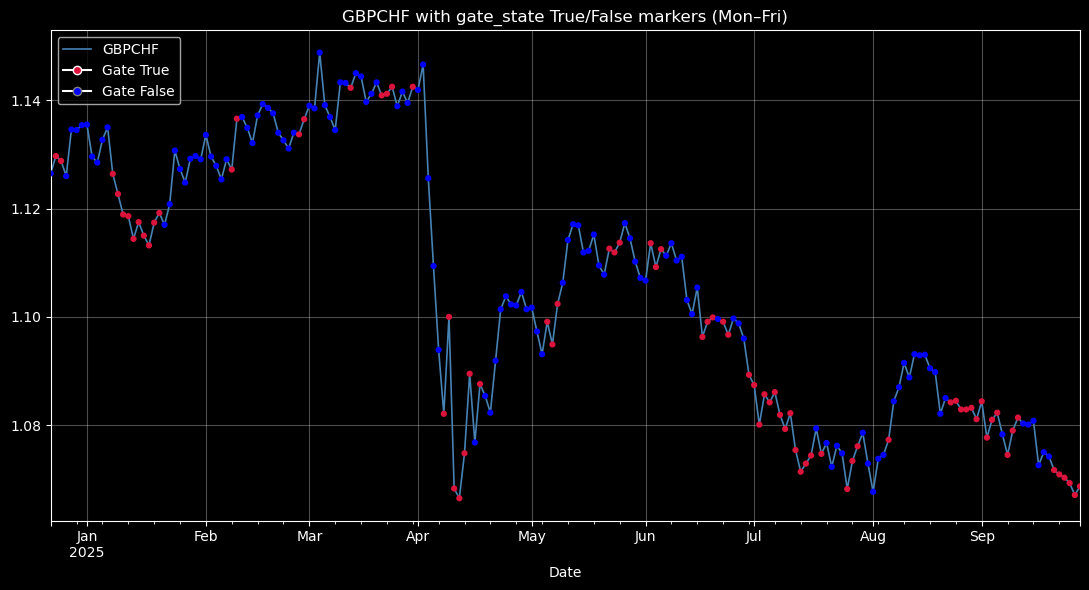

In [98]:
# Overlay gate_state decisions as per-day True/False markers on the price series
# Assumes you already have `s` (price series) and `gateon` (boolean series) defined
# Set how much tail to display (most recent N bars). Set to None for full history.
plt.style.use('dark_background')

TAIL_BARS = 200
# Use Mon–Fri only for plotting to avoid weekend prints often present in FX feeds
# s=s.tail(200)
s_std_plot = standardize_fx_daily_index(s)

# Select tail for plotting
s_plot = s_std_plot.tail(TAIL_BARS) if TAIL_BARS else s_std_plot
fig, ax = plt.subplots(figsize=(11, 6))
# Base price plot
s_plot.plot(ax=ax, color='steelblue', lw=1.2, label='GBPCHF')
# Align gate_state to price index (gate is Mon–Fri too)
g = gate_stateon.reindex(s_plot.index).fillna(False).astype(bool)
# print(f'gateon aligned to price (last 20 rows):\n{gate_stateon}')
# Overlay markers colored by gate_state state on the price series
colors = np.where(g.values, 'crimson', 'blue')
ax.scatter(s_plot.index, s_plot.values, c=colors, s=12, zorder=3)
# Legend: include price and gate_state state keys
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
gate_true = Line2D([0],[0], marker='o', color='w', label='Gate True', markerfacecolor='crimson', markersize=6)
gate_false = Line2D([0],[0], marker='o', color='w', label='Gate False', markerfacecolor='blue', markeredgecolor='gray', markersize=6)
ax.legend(handles + [gate_true, gate_false], labels + ['Gate True','Gate False'], loc='upper left')
ax.set_title('GBPCHF with gate_state True/False markers (Mon–Fri)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()